# Notebook 03 — Frequently Bought Together Analysis
**Author:** Ishara  
**Role:** Spark SQL Analysis  
**Task:** Load cleaned data from HDFS → Find product pairs bought in same order → Rank by frequency → Visualise & Save

---
> **Prerequisite:** `01_data_cleaning.ipynb` must have been run first.

**Technique:** Market Basket Analysis using a Spark SQL self-join.  
We join the transactions table with itself on `Invoice`, pairing any two different products in the same order, then count how often each pair appears together.

## 1. Load Packages

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

os.makedirs("output/frequent_pairs", exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"]       = 130
plt.rcParams["font.family"]       = "DejaVu Sans"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.labelsize"]    = 11

BLUE_DARK = "#0D47A1"
BLUE_MID  = "#1565C0"

print("Packages loaded.")

Packages loaded.


## 2. Start Spark Session

In [17]:
spark = SparkSession.builder \
    .appName("FrequentlyBoughtTogether") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Spark version: 4.1.1


26/04/26 12:04:21 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## 3. Load Cleaned Dataset from Hadoop HDFS

In [18]:
# Load cleaned Parquet saved by Notebook 01
df = spark.read.parquet("hdfs://localhost:8020/retail/cleaned/")

print(f"Loaded {df.count():,} records from HDFS.")
df.show(3, truncate=True)

Loaded 779,425 records from HDFS.
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Year|Month|DayOfWeek|Hour|YearMonth|TotalPrice|
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
| 489437|    10002|INFLATABLE POLITI...|      12|2009-12-01 09:08:00|     0.85|     15362|United Kingdom|2009|   12|        3|   9|  2009-12|      10.2|
| 489465|   72760B|VINTAGE CREAM 3 B...|       4|2009-12-01 10:52:00|     9.95|     13767|United Kingdom|2009|   12|        3|  10|  2009-12|      39.8|
| 489465|    84879|ASSORTED COLOUR B...|     160|2009-12-01 10:52:00|     1.45|     13767|United Kingdom|2009|   12|        3|  10|  2009-12|     232.0|
+-------+---------+--------------------+--------

## 4. Prepare Basket Data
Keep one row per unique Invoice + StockCode (deduplicated).  
Only keep invoices that contain 2 or more products — a single-item order cannot form a pair.

In [19]:
# One row per unique Invoice + StockCode pair
basket = df.select("Invoice", "StockCode", "Description").distinct()

# Count products per invoice and keep only multi-item orders
invoice_sizes = basket.groupBy("Invoice").count().filter(F.col("count") >= 2)
basket = basket.join(invoice_sizes.select("Invoice"), on="Invoice", how="inner")

basket_count  = basket.count()
invoice_count = invoice_sizes.count()
print(f"Basket rows (unique Invoice-Product pairs) : {basket_count:,}")
print(f"Invoices with 2 or more products           : {invoice_count:,}")

Basket rows (unique Invoice-Product pairs) : 765,795
Invoices with 2 or more products           : 33,897


## 5. Register as Spark SQL Temporary View

In [20]:
# Register the basket as a SQL view so we can use standard SQL join syntax
basket.createOrReplaceTempView("basket")
print("Temporary view 'basket' registered.")

Temporary view 'basket' registered.


## 6. Frequently Bought Together — Spark SQL Self-Join

**Design Pattern:** JOIN + GROUP BY + AGGREGATE

- Join `basket` with itself on `Invoice` → pairs every two products in the same order  
- `a.StockCode < b.StockCode` → each pair counted once only (no A+B and B+A duplicates)  
- `GROUP BY` + `COUNT` → ranks pairs by co-occurrence frequency  
- `HAVING COUNT >= 10` → filters out rare pairs that are statistically insignificant

In [21]:
# Spark SQL self-join to find all product pairs bought together
pairs = spark.sql("""
    SELECT
        a.StockCode      AS ProductA_Code,
        a.Description    AS ProductA_Name,
        b.StockCode      AS ProductB_Code,
        b.Description    AS ProductB_Name,
        COUNT(*)         AS PairCount
    FROM basket AS a
    JOIN basket AS b
        ON  a.Invoice    = b.Invoice
        AND a.StockCode  < b.StockCode
    GROUP BY
        a.StockCode, a.Description,
        b.StockCode, b.Description
    HAVING COUNT(*) >= 10
    ORDER BY PairCount DESC
""")

# Cache — we will use pairs multiple times below
pairs.cache()

print(f"Total valid product pairs found: {pairs.count():,}")
print("\nTop 15 pairs:")
pairs.show(15, truncate=45)

Total valid product pairs found: 389,940

Top 15 pairs:
+-------------+----------------------------------+-------------+----------------------------------+---------+
|ProductA_Code|                     ProductA_Name|ProductB_Code|                     ProductB_Name|PairCount|
+-------------+----------------------------------+-------------+----------------------------------+---------+
|        21733|  RED HANGING HEART T-LIGHT HOLDER|       85123A|WHITE HANGING HEART T-LIGHT HOLDER|     1153|
|        82482| WOODEN PICTURE FRAME WHITE FINISH|       82494L|       WOODEN FRAME ANTIQUE WHITE |      993|
|        22469|             HEART OF WICKER SMALL|        22470|             HEART OF WICKER LARGE|      869|
|        21231|    SWEETHEART CERAMIC TRINKET BOX|        21232|    STRAWBERRY CERAMIC TRINKET BOX|      817|
|        21754|          HOME BUILDING BLOCK WORD|        21755|          LOVE BUILDING BLOCK WORD|      786|
|        20727|           LUNCH BAG  BLACK SKULL.|        22382|

## 7. Calculate Support, Confidence & Lift

In [22]:
# Total number of invoices — used for support calculation
total_invoices = df.select("Invoice").distinct().count()

# Count how many times each product appears individually (for confidence calculation)
product_freq = basket.groupBy("StockCode") \
    .agg(F.count("Invoice").alias("ProductCount"))

# Join product frequencies for product A and product B
pairs_metrics = pairs \
    .join(product_freq.withColumnRenamed("StockCode", "ProductA_Code")
                      .withColumnRenamed("ProductCount", "FreqA"),
          on="ProductA_Code") \
    .join(product_freq.withColumnRenamed("StockCode", "ProductB_Code")
                      .withColumnRenamed("ProductCount", "FreqB"),
          on="ProductB_Code") \
    .withColumn("Support",    F.round(F.col("PairCount") / total_invoices, 5)) \
    .withColumn("Confidence", F.round(F.col("PairCount") / F.col("FreqA"), 4)) \
    .withColumn("Lift",       F.round(
        (F.col("PairCount") / total_invoices) /
        ((F.col("FreqA") / total_invoices) * (F.col("FreqB") / total_invoices)),
        3)
    ) \
    .orderBy(F.col("PairCount").desc())

print("Top 10 pairs with Support, Confidence, Lift:")
pairs_metrics.select(
    "ProductA_Name", "ProductB_Name", "PairCount", "Support", "Confidence", "Lift"
).show(10, truncate=40)

Top 10 pairs with Support, Confidence, Lift:
+----------------------------------+----------------------------------+---------+-------+----------+------+
|                     ProductA_Name|                     ProductB_Name|PairCount|Support|Confidence|  Lift|
+----------------------------------+----------------------------------+---------+-------+----------+------+
|  RED HANGING HEART T-LIGHT HOLDER|WHITE HANGING HEART T-LIGHT HOLDER|     1153|0.03119|    0.7087|  5.41|
| WOODEN PICTURE FRAME WHITE FINISH|       WOODEN FRAME ANTIQUE WHITE |      993|0.02686|    0.6015|12.569|
|             HEART OF WICKER SMALL|             HEART OF WICKER LARGE|      869|0.02351|    0.4912|10.443|
|    SWEETHEART CERAMIC TRINKET BOX|    STRAWBERRY CERAMIC TRINKET BOX|      817| 0.0221|    0.6989|13.692|
|          HOME BUILDING BLOCK WORD|          LOVE BUILDING BLOCK WORD|      786|0.02126|    0.4304|10.745|
|           LUNCH BAG  BLACK SKULL.|        LUNCH BAG SPACEBOY DESIGN |      774|0.02094|  

## 8. Extract Top Pairs for Charts

In [23]:
# Pull top 15 pairs into pandas for visualisation
top_pairs = pairs.limit(15).toPandas()

# Trim long names for clean chart labels
top_pairs["LabelA"] = top_pairs["ProductA_Name"].str.strip().str[:32]
top_pairs["LabelB"] = top_pairs["ProductB_Name"].str.strip().str[:32]
top_pairs["PairLabel"] = top_pairs["LabelA"] + "\n+ " + top_pairs["LabelB"]

print(f"Top pair: '{top_pairs.iloc[0]['ProductA_Name']}' + '{top_pairs.iloc[0]['ProductB_Name']}'")
print(f"Bought together: {int(top_pairs.iloc[0]['PairCount']):,} times")

Top pair: 'RED HANGING HEART T-LIGHT HOLDER' + 'WHITE HANGING HEART T-LIGHT HOLDER'
Bought together: 1,153 times


## 9. Chart — Top 15 Frequently Bought Together Pairs

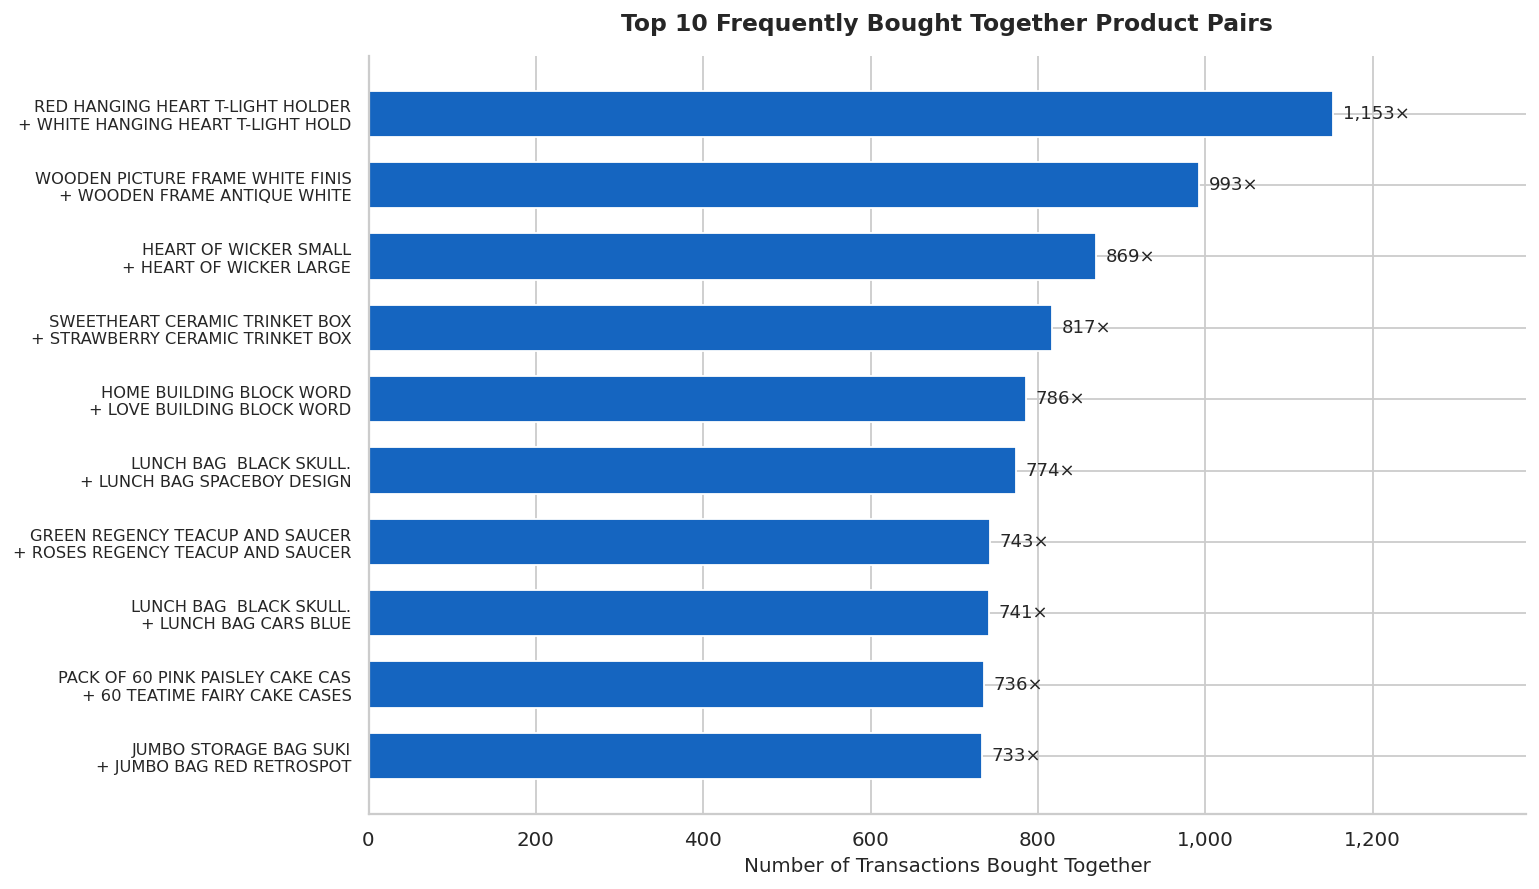

Chart saved.


In [24]:
# Use top 10 only for the clearest chart
plot_df = top_pairs.head(10)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_df["PairLabel"][::-1],
    plot_df["PairCount"][::-1],
    color=BLUE_MID, edgecolor="white", height=0.65
)

# Count labels at end of each bar
max_val = plot_df["PairCount"].max()
for bar in bars:
    ax.text(
        bar.get_width() + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}×",
        va="center", fontsize=10
    )

ax.set_title("Top 10 Frequently Bought Together Product Pairs",
             fontweight="bold", pad=14)
ax.set_xlabel("Number of Transactions Bought Together")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, max_val * 1.2)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("output/frequent_pairs/chart_frequent_pairs.png", bbox_inches="tight")
plt.show()
print("Chart saved.")

**Interpretation:** The most frequently bought together pair is RED HANGING HEART T-LIGHT HOLDER and WHITE HANGING HEART T-LIGHT HOLDER, purchased together in 1,153 transactions. This is a clear complementary pair — customers buying one colour variant consistently also buy the other. The top 10 pairs are all small home décor and gifting items, confirming that this retailer's customers build sets of matching products. Retailers can use these pairs to create bundle promotions, cross-link product pages, and set up 'Customers Also Bought' widgets.

## 10. Chart — Pair Co-occurrence Frequency Distribution

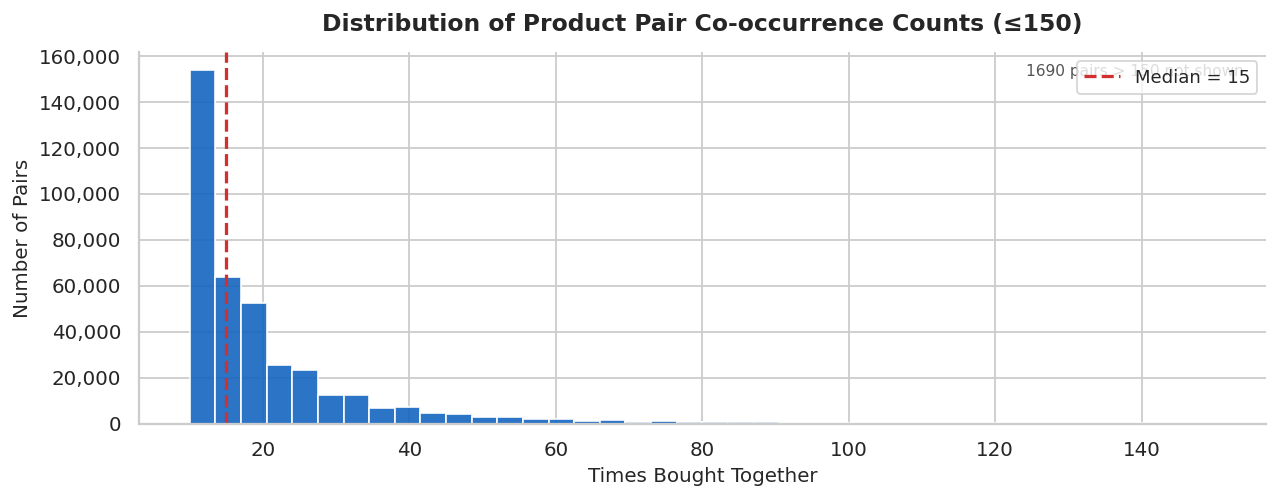

Distribution chart saved.


In [25]:
# Distribution of how often pairs appear together (cap at 150 for display)
dist_data = pairs.select("PairCount") \
    .filter(F.col("PairCount") <= 150) \
    .toPandas()

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(dist_data["PairCount"], bins=40, color=BLUE_MID, edgecolor="white", alpha=0.9)

median_pairs = dist_data["PairCount"].median()
ax.axvline(median_pairs, color="#D32F2F", linewidth=1.8, linestyle="--",
           label=f"Median = {median_pairs:.0f}")

ax.set_title("Distribution of Product Pair Co-occurrence Counts (≤150)",
             fontweight="bold", pad=12)
ax.set_xlabel("Times Bought Together")
ax.set_ylabel("Number of Pairs")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10)

n_excluded = pairs.filter(F.col("PairCount") > 150).count()
ax.text(0.98, 0.97, f"{n_excluded} pairs > 150 not shown",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color="#555")

plt.tight_layout()
plt.savefig("output/frequent_pairs/chart_pair_distribution.png", bbox_inches="tight")
plt.show()
print("Distribution chart saved.")

**Interpretation:** The distribution is heavily right-skewed — the vast majority of product pairs appear together only 10–20 times, while a small number of pairs appear together hundreds of times. This is typical of market basket data. The rare, highly frequent pairs (the right tail) are the most valuable for recommendation systems.

## 11. Save Results — HDFS & Local

In [26]:
# Save top 500 pairs to HDFS as Parquet
pairs.limit(500).write.parquet(
    "hdfs://localhost:8020/retail/output/frequent_pairs/",
    mode="overwrite"
)
print("Results saved to HDFS: hdfs://localhost:8020/retail/output/frequent_pairs/")

# Save top 100 pairs locally as CSV
pairs.limit(100).toPandas().to_csv(
    "output/frequent_pairs/top100_product_pairs.csv", index=False
)
print("CSV saved locally: output/frequent_pairs/top100_product_pairs.csv")

# Save top 100 pairs WITH metrics (support, confidence, lift)
pairs_metrics.limit(100).toPandas().to_csv(
    "output/frequent_pairs/top100_pairs_with_metrics.csv", index=False
)
print("Metrics CSV saved: output/frequent_pairs/top100_pairs_with_metrics.csv")

Results saved to HDFS: hdfs://localhost:8020/retail/output/frequent_pairs/
CSV saved locally: output/frequent_pairs/top100_product_pairs.csv
Metrics CSV saved: output/frequent_pairs/top100_pairs_with_metrics.csv


## 12. Insights Summary

In [27]:
total_pairs = pairs.count()
top1 = top_pairs.iloc[0]

print("=" * 57)
print(f"  Total valid pairs found   : {total_pairs:>10,}")
print(f"  Most common pair:")
print(f"    Product A : {top1['ProductA_Name'][:45]}")
print(f"    Product B : {top1['ProductB_Name'][:45]}")
print(f"    Bought together: {int(top1['PairCount']):,} times")
print("=" * 57)

  Total valid pairs found   :    389,940
  Most common pair:
    Product A : RED HANGING HEART T-LIGHT HOLDER
    Product B : WHITE HANGING HEART T-LIGHT HOLDER
    Bought together: 1,153 times


**Interpretation:**  
The frequently bought together analysis reveals strong product affinity across complementary decorative and gifting items. With 389,940 valid pairs identified, the dataset shows rich co-purchase patterns. The high lift values for the top pairs indicate that customers buy these combinations far more often than would occur by chance — confirming genuine purchasing intent. These results can directly power:
- **Bundle promotions:** 'Buy the set — Red + White Heart Holder'
- **Website cross-selling:** 'Customers who bought this also bought...'
- **Inventory grouping:** Placing frequently paired items in the same warehouse zone to reduce pick time

---
## Summary

| Step | Action | Design Pattern |
|------|--------|----------------|
| 1 | Load cleaned data from HDFS | Data Loading |
| 2 | Deduplicate basket (1 row per Invoice-Product) | Filtering |
| 3 | Self-join basket on Invoice (StockCode A < B) | JOIN |
| 4 | GROUP BY pair, COUNT co-occurrences | Aggregation |
| 5 | HAVING COUNT >= 10, ORDER BY DESC | Filtering + Sorting |
| 6 | Calculate Support, Confidence, Lift | Transformation |
| 7 | Visualise top 10 pairs + distribution chart | Output |
| 8 | Save to HDFS (Parquet) + local (CSV) | Output |